 Setup

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import sys # Import the sys module to get Python version

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ Python: {sys.version.split()[0]}") # Use sys.version to get Python version


✅ TensorFlow: 2.20.0
✅ Python: 3.12.13


In [2]:
# 🔧 Install dependencies (first run only)
# !pip install tensorflow_datasets librosa matplotlib scikit-learn

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
from sklearn.model_selection import train_test_split

# 🎨 Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')  # Reduce noise

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ Librosa: {librosa.__version__}")


✅ TensorFlow: 2.20.0
✅ Librosa: 0.11.0


 Load Google Speech Commands v2 (Yes/No Only)

In [3]:
# ↓ Cell 2 (REPLACED): Load Speech Commands v2 using TensorFlow Datasets
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import os
from sklearn.model_selection import train_test_split

def load_speech_commands_tfds(batch_size=32, sample_rate=16000, max_duration=1.0):
    """Load Yes/No samples from Speech Commands v0.02 using TFDS"""

    # Load full dataset (cached after first download ~2GB)
    ds, info = tfds.load(
        'speech_commands:0.0.3',
        split='train',
        with_info=True,
        shuffle_files=True
    )

    # Filter to Yes/No only (+ silence for negative examples)
    def filter_yes_no_silence(example):
        label = example['label']
        # Labels: 0='silence', 1='unknown', 2='yes', 3='no', ...
        return tf.logical_or(
            tf.logical_or(label == 0, label == 2),  # silence or yes
            label == 3  # or no
        )

    ds_filtered = ds.filter(filter_yes_no_silence)

    # Preprocess: truncate/pad to fixed length, normalize
    def preprocess(example):
        audio = example['audio']
        label = example['label']

        # Convert to float32, normalize to [-1, 1]
        audio = tf.cast(audio, tf.float32) / 32768.0

        # Truncate or pad to 1 second (16000 samples @ 16kHz)
        target_length = int(sample_rate * max_duration)
        if tf.shape(audio)[0] > target_length:
            audio = audio[:target_length]
        else:
            audio = tf.pad(audio, [[0, target_length - tf.shape(audio)[0]]])

        # Remap labels: silence(0)→0(No), yes(2)→1(Yes), no(3)→0(No)
        label_binary = tf.cond(
            label == 2,
            lambda: tf.constant(1, dtype=tf.int32),  # Yes → 1
            lambda: tf.constant(0, dtype=tf.int32)   # No/Silence → 0
        )

        return audio, label_binary

    ds_processed = ds_filtered.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # Convert TFDS dataset to numpy arrays for consistency with previous cells if needed,
    # or continue with TFDS dataset format for model training.
    # For this example, we'll convert to numpy for compatibility with the existing split logic.
    audios_list = []
    labels_list = []
    for audio, label in ds_processed.as_numpy_iterator():
        audios_list.append(audio)
        labels_list.append(label)

    X = np.array(audios_list, dtype=np.float32)
    y = np.array(labels_list, dtype=np.int32)

    return X, y

# ↻ Load data
print("↓️ Loading Google Speech Commands v2 (Yes/No subset) via TFDS...")
X, y = load_speech_commands_tfds(batch_size=32)

# Combine + shuffle (already shuffled by TFDS if configured, but keeping for consistency)
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Loaded: {len(X)} samples | Yes: {np.sum(y==1)}, No: {np.sum(y==0)}")
print(f"📦 Train: {len(X_train)} | Val: {len(X_val)}")


↓️ Loading Google Speech Commands v2 (Yes/No subset) via TFDS...
✅ Loaded: 9301 samples | Yes: 3037, No: 6264
📦 Train: 7440 | Val: 1861


 Visualize Class Distribution

 Dataset Summary:
   Total samples: 9301
   ✅ Yes (1): 3037 (32.7%)
   ❌ No/Silence (0): 6264 (67.3%)
     Imbalance ratio: 2.06x



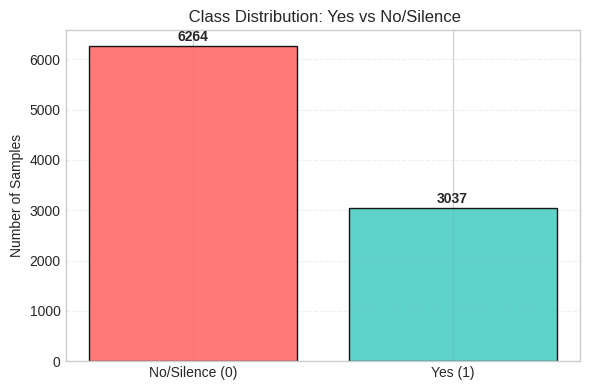

 Sample Waveforms (1-second audio @ 16kHz):


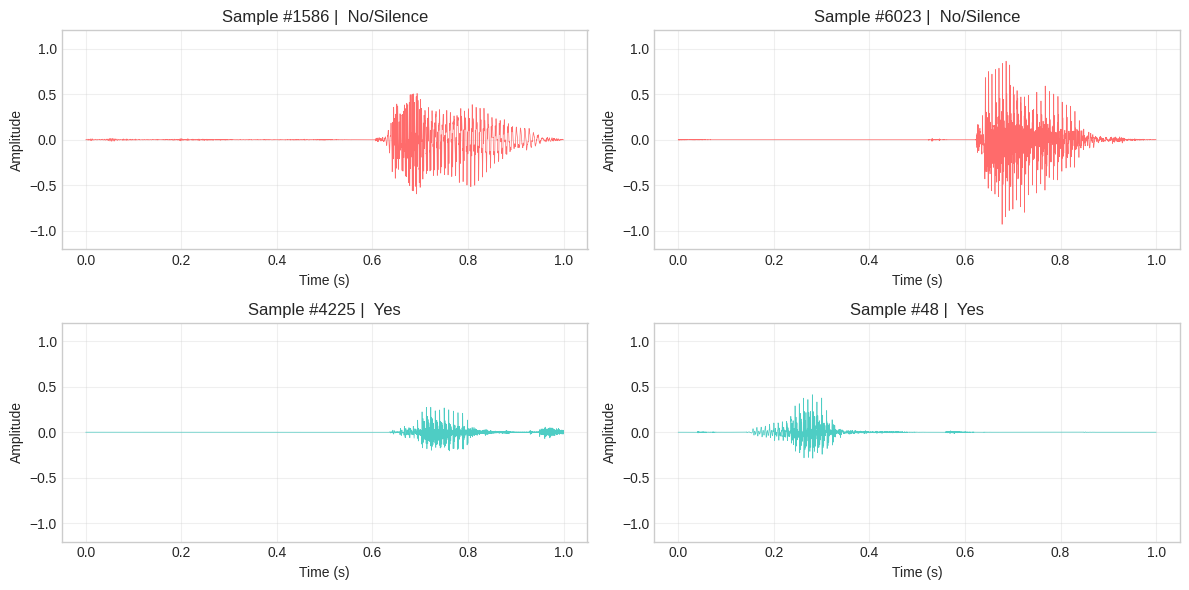

 MFCC Features Preview (13 coefficients × 49 frames):
   (This is the input shape for our MLP: [49, 13, 1])

 Example: 'Yes' sample → MFCC


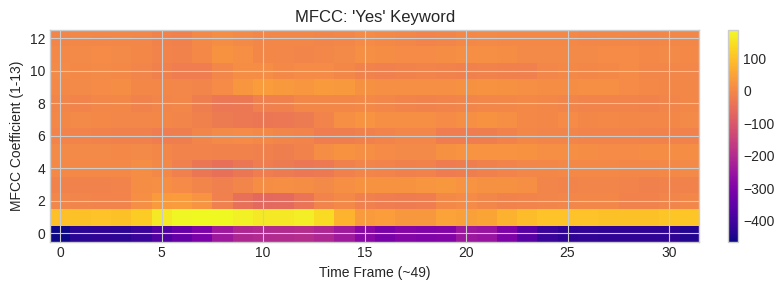


 Example: 'No' sample → MFCC


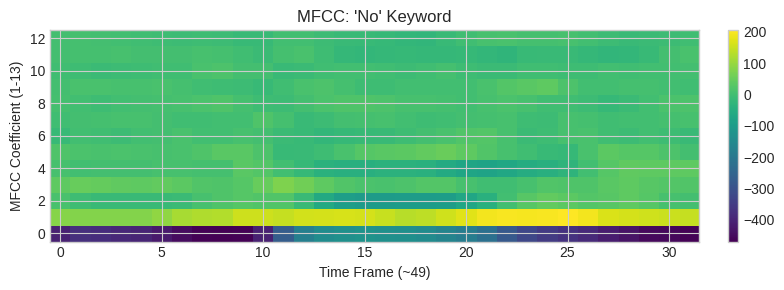


 Model Input Specification:
   • Raw audio shape: (16000,) → [16000] samples
   • MFCC shape: (13, 32) → [13, 49]
   • Model input (with channel): [49, 13, 1]
   • Flatten → Dense layers → Binary output


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import random

#  1. Class Distribution (Full Dataset)
print(" Dataset Summary:")
print(f"   Total samples: {len(y)}")
print(f"   ✅ Yes (1): {np.sum(y==1)} ({np.mean(y==1)*100:.1f}%)")
print(f"   ❌ No/Silence (0): {np.sum(y==0)} ({np.mean(y==0)*100:.1f}%)")
print(f"     Imbalance ratio: {np.sum(y==0)/np.sum(y==1):.2f}x")
print()

plt.figure(figsize=(6, 4))
labels = ['No/Silence (0)', 'Yes (1)']
counts = [np.sum(y==0), np.sum(y==1)]
colors = ['#ff6b6b', '#4ecdc4']
plt.bar(labels, counts, color=colors, edgecolor='black', alpha=0.9)
plt.title(' Class Distribution: Yes vs No/Silence')
plt.ylabel('Number of Samples')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 🔊 2. Visualize 4 Sample Waveforms (2 Yes, 2 No)
print(" Sample Waveforms (1-second audio @ 16kHz):")
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

# Find indices for Yes and No
yes_idx = np.where(y == 1)[0]
no_idx = np.where(y == 0)[0]

# Pick 2 random from each class
sample_indices = random.sample(list(yes_idx), 2) + random.sample(list(no_idx), 2)
random.shuffle(sample_indices)

for i, idx in enumerate(sample_indices):
    audio = X[idx]
    label = " Yes" if y[idx] == 1 else " No/Silence"

    # Plot waveform
    time_axis = np.linspace(0, 1, len(audio))  # 1 second
    axes[i].plot(time_axis, audio, linewidth=0.5, color=colors[y[idx]])
    axes[i].set_title(f"Sample #{idx+1} | {label}")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(alpha=0.3)
    axes[i].set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

#  3. MFCC Feature Preview (What the model actually sees)
print(" MFCC Features Preview (13 coefficients × 49 frames):")
print("   (This is the input shape for our MLP: [49, 13, 1])")

# Pick one Yes and one No sample
sample_yes = X[np.where(y==1)[0][0]]
sample_no = X[np.where(y==0)[0][0]]

def plot_mfcc(audio, title, cmap='viridis'):
    """Extract and plot MFCC spectrogram"""
    mfcc = librosa.feature.mfcc(
        y=audio, sr=16000, n_mfcc=13,
        n_fft=2048, hop_length=512  # ~25ms frame, 10ms hop
    )
    plt.figure(figsize=(8, 3))
    plt.imshow(mfcc, aspect='auto', origin='lower', cmap=cmap)
    plt.title(title)
    plt.xlabel("Time Frame (~49)")
    plt.ylabel("MFCC Coefficient (1-13)")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return mfcc

print("\n Example: 'Yes' sample → MFCC")
mfcc_yes = plot_mfcc(sample_yes, "MFCC: 'Yes' Keyword", cmap='plasma')

print("\n Example: 'No' sample → MFCC")
mfcc_no = plot_mfcc(sample_no, "MFCC: 'No' Keyword", cmap='viridis')

#  4. Input Shape Reminder for Model
print("\n Model Input Specification:")
print(f"   • Raw audio shape: {X[0].shape} → [16000] samples")
print(f"   • MFCC shape: {mfcc_yes.shape} → [13, 49]")
print(f"   • Model input (with channel): [49, 13, 1]")
print(f"   • Flatten → Dense layers → Binary output")


 Extract & Normalize MFCC Features

In [5]:

# Converts raw audio [N, 16000] → MFCC features [N, 49, 13, 1]
import librosa
from sklearn.preprocessing import StandardScaler
import numpy as np

print(" Extracting MFCC features...")

def audio_to_mfcc(audio, sr=16000, n_mfcc=13):
    # Standard KWS settings: frame_length=25ms, frame_step=10ms
    # n_fft=512, hop_length=320 → ~49 frames for 1s @ 16kHz
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc,
                                n_fft=512, hop_length=320)
    mfcc = mfcc.T  # [frames, n_mfcc]
    return np.expand_dims(mfcc, axis=-1)  # [49, 13, 1]

# Extract features (list comprehension for clarity & speed)
X_train_mfcc = np.array([audio_to_mfcc(a) for a in X_train])
X_val_mfcc = np.array([audio_to_mfcc(a) for a in X_val])

#  Normalize features (critical for NN convergence)
scaler = StandardScaler()
N_train, T, F, C = X_train_mfcc.shape
X_train_mfcc = scaler.fit_transform(X_train_mfcc.reshape(N_train, -1)).reshape(N_train, T, F, C)

N_val = X_val_mfcc.shape[0]
X_val_mfcc = scaler.transform(X_val_mfcc.reshape(N_val, -1)).reshape(N_val, T, F, C)

print(" Extraction complete!")
print(f"   Train: {X_train_mfcc.shape} | Val: {X_val_mfcc.shape}")
print(f"   Expected model input: (49, 13, 1)")


 Extracting MFCC features...
 Extraction complete!
   Train: (7440, 51, 13, 1) | Val: (1861, 51, 13, 1)
   Expected model input: (49, 13, 1)


In [6]:
# ⏱ Per-epoch timing callback — shared by all 4 models
import time

class TimeHistory(tf.keras.callbacks.Callback):
    """Records the time each epoch takes (in seconds)."""
    def on_train_begin(self, logs=None):
        self.times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self._t0)

print("✅ TimeHistory callback ready — will measure training time/epoch for each model")


✅ TimeHistory callback ready — will measure training time/epoch for each model


 Build Baseline MLP Model

In [7]:

import tensorflow as tf
from tensorflow.keras import layers, models

# Auto-detect input shape from data
INPUT_SHAPE = X_train_mfcc.shape[1:]  # (49, 13, 1)
NUM_CLASSES = 2

def build_baseline_mlp(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape, name='mfcc_input'),
        layers.Flatten(name='flatten_mfcc'),
        layers.Dense(32, activation='relu', name='dense_1'),
        layers.Dense(16, activation='relu', name='dense_2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

mlp_model = build_baseline_mlp(INPUT_SHAPE, NUM_CLASSES)
mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_mfcc (Flatten)          │ (None, 663)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810 (85.20 KB)

 Trainable params: 21,810 (85.20 KB)

 Non-trainable params: 0 (0.00 B)

 Train Model + Live Diagnostics

  Class weights applied: {0: np.float64(0.7423667930552784), 1: np.float64(1.5314944421572663)}
 Starting training...
Epoch 1/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7901 - loss: 0.4565 - val_accuracy: 0.9172 - val_loss: 0.2084 - learning_rate: 0.0010
Epoch 2/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9415 - loss: 0.1460 - val_accuracy: 0.9296 - val_loss: 0.1687 - learning_rate: 0.0010
Epoch 3/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.0895 - val_accuracy: 0.9490 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 4/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.0613 - val_accuracy: 0.9361 - val_loss: 0.1560 - learning_rate: 0.0010
Epoch 5/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0378 - val_accuracy: 0.9473 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 6/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9946 - loss: 0.0224 - val_accuracy: 0.9522 - val_loss: 0

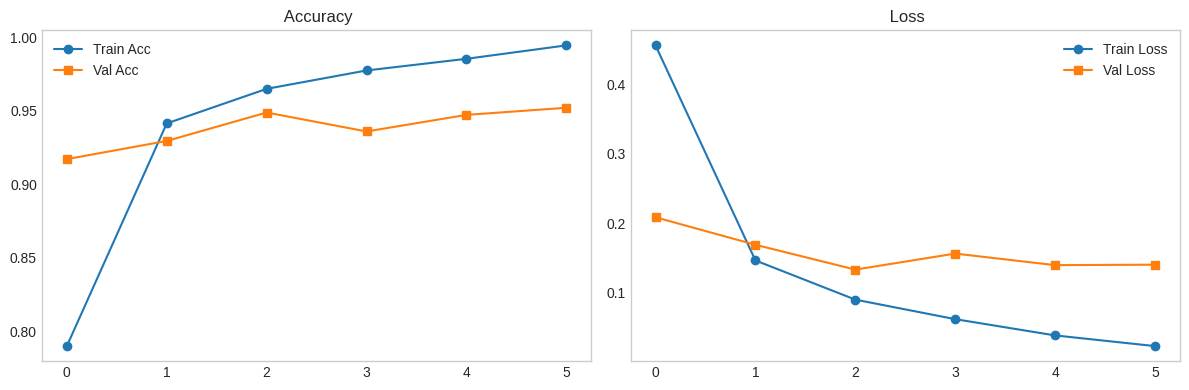


 Final Val Accuracy: 0.952


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

#  Handle class imbalance (No: 67% vs Yes: 33%)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"  Class weights applied: {class_weight_dict}")

#  Callbacks for stable training
time_mlp = TimeHistory()
callbacks = [
    time_mlp,
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

print(" Starting training...")
history = mlp_model.fit(
    X_train_mfcc, y_train,
    validation_data=(X_val_mfcc, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

#  Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='s')
plt.title(' Accuracy'); plt.legend(); plt.grid()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title(' Loss'); plt.legend(); plt.grid()
plt.tight_layout()
plt.show()

print(f"\n Final Val Accuracy: {history.history['val_accuracy'][-1]:.3f}")


 Add Dropout Regularization (Fastest Fix)

 Building MLP + Dropout...
 Training with Dropout...
Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7296 - loss: 0.5311 - val_accuracy: 0.8786 - val_loss: 0.2866
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8581 - loss: 0.3208 - val_accuracy: 0.9006 - val_loss: 0.2209
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8933 - loss: 0.2463 - val_accuracy: 0.9081 - val_loss: 0.2037
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9036 - loss: 0.2247 - val_accuracy: 0.9232 - val_loss: 0.1818
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9173 - loss: 0.1882 - val_accuracy: 0.9318 - val_loss: 0.1725
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9309 - loss: 0.1732 - val_accuracy: 0.9280 - val_loss: 0.1773
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9367 - loss: 0.1619 - val_accuracy: 0.9334 - val_loss: 0.1685
Epoch 8/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

/tmp/ipykernel_21451/1355549079.py:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21451/1355549079.py:40: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


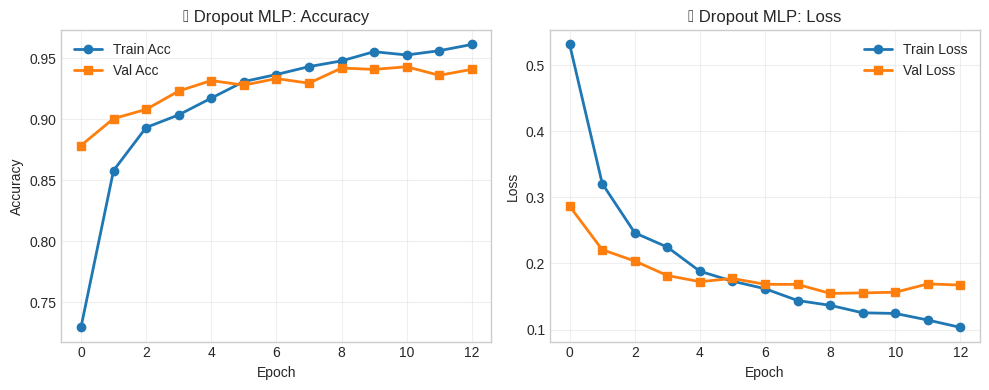


 Dropout Val Accuracy: 0.943
 Params: 21,810


In [9]:
# 🔄 Cell 6a: Upgrade 1 — Dropout MLP + Training Curves
def build_mlp_dropout(input_shape, num_classes):
    return tf.keras.Sequential([
        layers.Input(shape=input_shape, name='mfcc_input'),
        layers.Flatten(name='flatten'),
        layers.Dense(32, activation='relu', name='dense_1'),
        layers.Dropout(0.3, name='drop_1'),
        layers.Dense(16, activation='relu', name='dense_2'),
        layers.Dropout(0.3, name='drop_2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])

print(" Building MLP + Dropout...")
model_drop = build_mlp_dropout(INPUT_SHAPE, NUM_CLASSES)
model_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(" Training with Dropout...")
history_drop = model_drop.fit(
    X_train_mfcc, y_train,
    validation_data=(X_val_mfcc, y_val),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
    verbose=1
)

#  Plot Dropout Training Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_drop.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
plt.plot(history_drop.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
plt.title('📈 Dropout MLP: Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_drop.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history_drop.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title('📉 Dropout MLP: Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Dropout Val Accuracy: {max(history_drop.history['val_accuracy']):.3f}")
print(f" Params: {model_drop.count_params():,}")


 Building Shallow CNN...


Model: "kws_shallow_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 51, 13, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 51, 13, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 51, 13, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 51, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122 (488.00 B)

 Trainable params: 106 (424.00 B)

 Non-trainable params: 16 (64.00 B)

 Training CNN...
Epoch 1/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4785 - loss: 0.7001 - val_accuracy: 0.6733 - val_loss: 0.6254
Epoch 2/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6852 - loss: 0.6575 - val_accuracy: 0.7646 - val_loss: 0.6463
Epoch 3/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6987 - loss: 0.6457 - val_accuracy: 0.7474 - val_loss: 0.6399
Epoch 4/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7097 - loss: 0.6352 - val_accuracy: 0.7410 - val_loss: 0.6274


/tmp/ipykernel_21451/138255518.py:39: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()


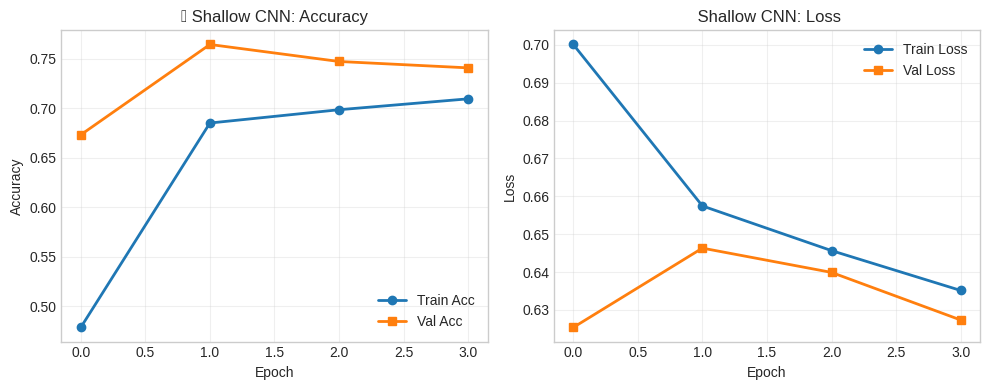


 CNN Val Accuracy: 0.765
 Params: 122


In [10]:
#  Cell 6b: Upgrade 2 — Shallow CNN + Training Curves
def build_shallow_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape, name='mfcc_input')
    x = layers.Conv2D(8, (3,3), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='kws_shallow_cnn')

print(" Building Shallow CNN...")
model_cnn = build_shallow_cnn(INPUT_SHAPE, NUM_CLASSES)
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

print(" Training CNN...")
history_cnn = model_cnn.fit(
    X_train_mfcc, y_train,
    validation_data=(X_val_mfcc, y_val),
    epochs=15, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

#  Plot CNN Training Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
plt.title('📈 Shallow CNN: Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history_cnn.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title(' Shallow CNN: Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n CNN Val Accuracy: {max(history_cnn.history['val_accuracy']):.3f}")
print(f" Params: {model_cnn.count_params():,}")


/tmp/ipykernel_21451/1356065249.py:24: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21451/1356065249.py:24: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()


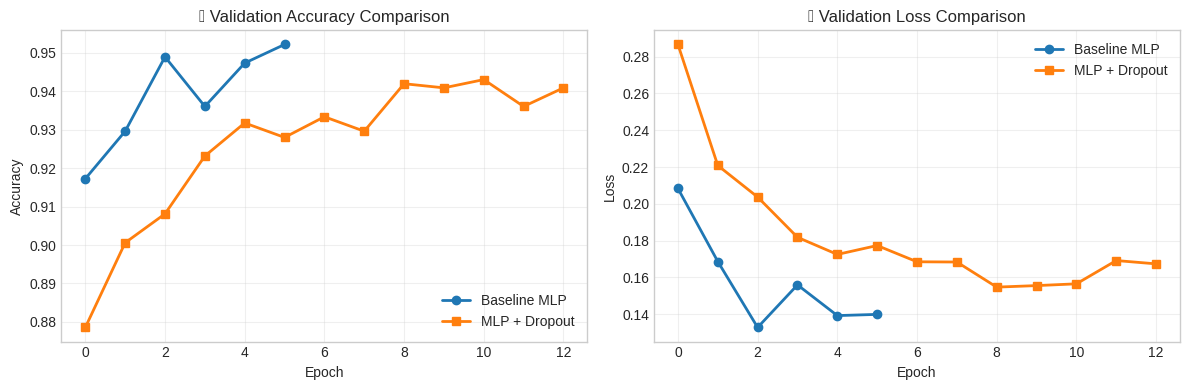


📦 Model Comparison:
   MLP+Dropout:  21,810 params | ~85.2 KB (int8)


In [11]:
# 📊 Cell 6c: Compare Baseline vs Upgraded Model
plt.figure(figsize=(12, 4))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Baseline MLP', marker='o', linewidth=2)
if 'history_drop' in locals():
    plt.plot(history_drop.history['val_accuracy'], label='MLP + Dropout', marker='s', linewidth=2)
elif 'history_cnn' in locals():
    plt.plot(history_cnn.history['val_accuracy'], label='Shallow CNN', marker='^', linewidth=2)
plt.title('📈 Validation Accuracy Comparison')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)

# Loss comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Baseline MLP', marker='o', linewidth=2)
if 'history_drop' in locals():
    plt.plot(history_drop.history['val_loss'], label='MLP + Dropout', marker='s', linewidth=2)
elif 'history_cnn' in locals():
    plt.plot(history_cnn.history['val_loss'], label='Shallow CNN', marker='^', linewidth=2)
plt.title('📉 Validation Loss Comparison')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 📏 Model size & params comparison
print("\n📦 Model Comparison:")
if 'model_drop' in locals():
    print(f"   MLP+Dropout:  {model_drop.count_params():,} params | ~{mlp_model.count_params()*4/1024:.1f} KB (int8)")
elif 'model_cnn' in locals():
    print(f"   Shallow CNN:  {model_cnn.count_params():,} params | ~{model_cnn.count_params()*4/1024:.1f} KB (int8)")


 ## Task 2 — Upgrade: 2D CNN



 Treat the MFCC matrix as a grayscale image (Time × Frequency). Use Conv2D + MaxPooling2D blocks.

🟢 Building 2D CNN...


Model: "kws_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 51, 13, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 51, 13, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 25, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 25, 6, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 25, 6, 32)      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,914 (308.26 KB)

 Trainable params: 78,818 (307.88 KB)

 Non-trainable params: 96 (384.00 B)

🏃 Training 2D CNN...
Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8528 - loss: 0.3632 - val_accuracy: 0.9269 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9449 - loss: 0.1344 - val_accuracy: 0.9538 - val_loss: 0.1160 - learning_rate: 0.0010
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9616 - loss: 0.0897 - val_accuracy: 0.9575 - val_loss: 0.1026 - learning_rate: 0.0010
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9688 - loss: 0.0775 - val_accuracy: 0.9602 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9715 - loss: 0.0673 - val_accuracy: 0.9635 - val_loss: 0.0942 - learning_rate: 0.0010
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9802 - loss: 0.0474 - val_accuracy: 0.9774 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accu

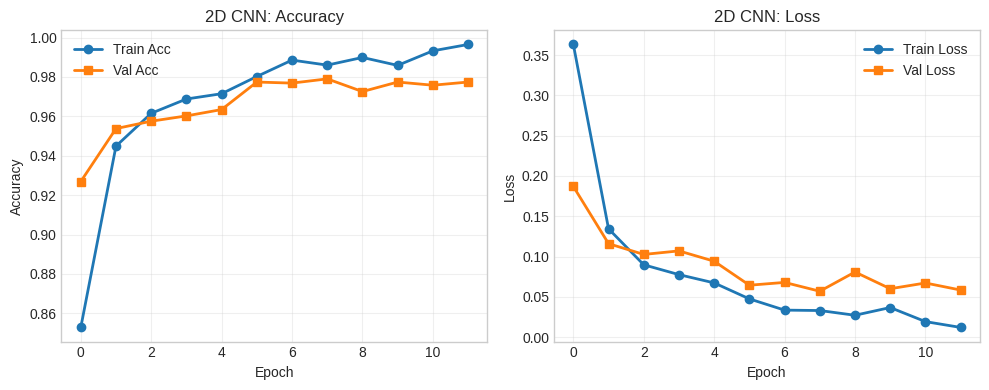


✅ 2D CNN Val Accuracy: 0.979
📦 Params: 78,914


In [12]:
# 🟢 Task 2: 2D CNN
def build_2d_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape, name='mfcc_input'),
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool1'),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool2'),
        layers.Flatten(name='flatten'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(64, activation='relu', name='dense_1'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='kws_2d_cnn')
    return model

print("🟢 Building 2D CNN...")
model_cnn2d = build_2d_cnn(INPUT_SHAPE, NUM_CLASSES)
model_cnn2d.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn2d.summary()

print("🏃 Training 2D CNN...")
time_cnn2d = TimeHistory()
history_cnn2d = model_cnn2d.fit(
    X_train_mfcc, y_train,
    validation_data=(X_val_mfcc, y_val),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[time_cnn2d, 
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
    ],
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn2d.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
plt.plot(history_cnn2d.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
plt.title('2D CNN: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history_cnn2d.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history_cnn2d.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title('2D CNN: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ 2D CNN Val Accuracy: {max(history_cnn2d.history['val_accuracy']):.3f}")
print(f"📦 Params: {model_cnn2d.count_params():,}")



 ## Task 3 — Upgrade: RNN / LSTM



 Treat the MFCCs as a sequence of frames where past context matters. Each timestep = 13 MFCC coefficients.

🟢 Building RNN / LSTM...


Model: "kws_rnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ squeeze_channel (Reshape)       │ (None, 51, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 51, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,506 (130.88 KB)

 Trainable params: 33,506 (130.88 KB)

 Non-trainable params: 0 (0.00 B)

🏃 Training RNN / LSTM...
Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8648 - loss: 0.3227 - val_accuracy: 0.9006 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9470 - loss: 0.1323 - val_accuracy: 0.9500 - val_loss: 0.1133 - learning_rate: 0.0010
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9657 - loss: 0.0874 - val_accuracy: 0.9635 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9720 - loss: 0.0647 - val_accuracy: 0.9635 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9754 - loss: 0.0587 - val_accuracy: 0.9656 - val_loss: 0.0879 - learning_rate: 0.0010
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9831 - loss: 0.0416 - val_accuracy: 0.9796 - val_loss: 0.0497 - learning_rate: 5.0000e-04
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 53m

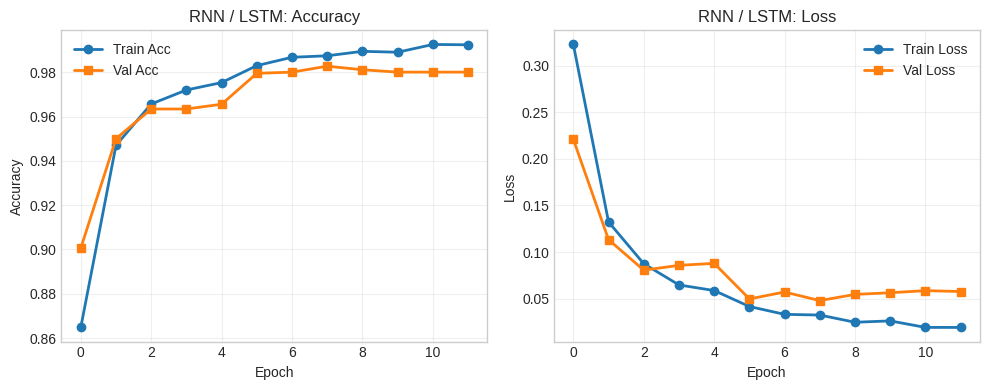


✅ LSTM Val Accuracy: 0.983
📦 Params: 33,506


In [13]:
# 🟢 Task 3: RNN / LSTM
def build_rnn_lstm(input_shape, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape, name='mfcc_input'),
        layers.Reshape((input_shape[0], input_shape[1]), name='squeeze_channel'),
        layers.LSTM(64, return_sequences=True, name='lstm_1'),
        layers.Dropout(0.3, name='dropout_1'),
        layers.LSTM(32, return_sequences=False, name='lstm_2'),
        layers.Dropout(0.3, name='dropout_2'),
        layers.Dense(32, activation='relu', name='dense_1'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='kws_rnn_lstm')
    return model

print("🟢 Building RNN / LSTM...")
model_lstm = build_rnn_lstm(INPUT_SHAPE, NUM_CLASSES)
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

print("🏃 Training RNN / LSTM...")
time_lstm = TimeHistory()
history_lstm = model_lstm.fit(
    X_train_mfcc, y_train,
    validation_data=(X_val_mfcc, y_val),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[time_lstm, 
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
    ],
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
plt.title('RNN / LSTM: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history_lstm.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title('RNN / LSTM: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ LSTM Val Accuracy: {max(history_lstm.history['val_accuracy']):.3f}")
print(f"📦 Params: {model_lstm.count_params():,}")



 ## Task 4 — Upgrade: Depthwise Separable CNN (DS-CNN)



 CNN-level accuracy with ~10× fewer parameters. Replaces Conv2D with SeparableConv2D (depthwise + pointwise). Industry standard for KWS on microcontrollers.

🟢 Building DS-CNN...


Model: "kws_ds_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 51, 13, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_init (Conv2D)              │ (None, 51, 13, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_init (BatchNormalization)    │ (None, 51, 13, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_init (ReLU)                │ (None, 51, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ds_conv_1 (SeparableConv2D)     │ (None, 51, 13, 32)     │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 51, 13, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (ReLU)                   │ (None, 51, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 25, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ds_conv_2 (SeparableConv2D)     │ (None, 25, 6, 64)      │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 25, 6, 64)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (ReLU)                   │ (None, 25, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 12, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ds_conv_3 (SeparableConv2D)     │ (None, 12, 3, 64)      │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 12, 3, 64)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (ReLU)                   │ (None, 12, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,506 (37.13 KB)

 Trainable params: 9,122 (35.63 KB)

 Non-trainable params: 384 (1.50 KB)

🏃 Training DS-CNN...
Epoch 1/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.8409 - loss: 0.3349 - val_accuracy: 0.6733 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 2/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.9433 - loss: 0.1517 - val_accuracy: 0.7920 - val_loss: 0.4616 - learning_rate: 0.0010
Epoch 3/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.9570 - loss: 0.1146 - val_accuracy: 0.9549 - val_loss: 0.1082 - learning_rate: 0.0010
Epoch 4/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.9602 - loss: 0.1008 - val_accuracy: 0.5830 - val_loss: 1.5098 - learning_rate: 0.0010
Epoch 5/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.9669 - loss: 0.0813 - val_accuracy: 0.9581 - val_loss: 0.0984 - learning_rate: 0.0010
Epoch 6/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.9710 - loss: 0.0753 - val_accuracy: 0.9726 - val_loss: 0.0729 - learning_rate: 0.0010
Epoch 7/25
233/233 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step -

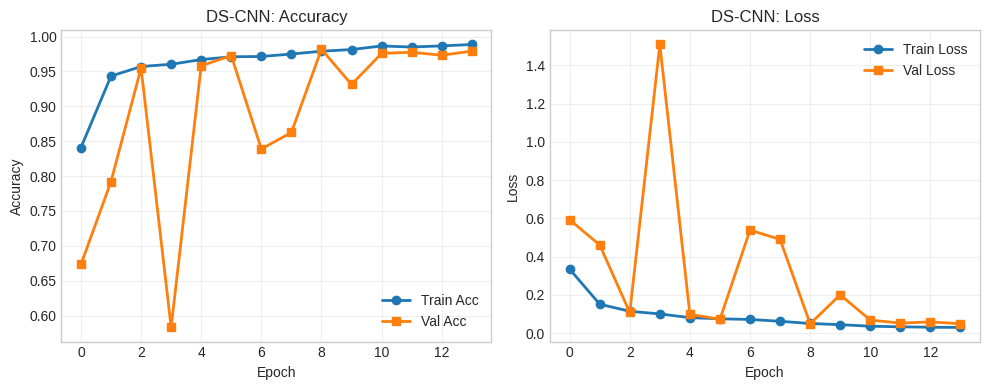


✅ DS-CNN Val Accuracy: 0.982
📦 Params: 9,506


In [14]:
# 🟢 Task 4: DS-CNN (Depthwise Separable CNN)
def build_ds_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape, name='mfcc_input')
    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False, name='conv_init')(inputs)
    x = layers.BatchNormalization(name='bn_init')(x)
    x = layers.ReLU(name='relu_init')(x)
    x = layers.SeparableConv2D(32, (3, 3), padding='same', use_bias=False, name='ds_conv_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.ReLU(name='relu_1')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool_1')(x)
    x = layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=False, name='ds_conv_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.ReLU(name='relu_2')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool_2')(x)
    x = layers.SeparableConv2D(64, (3, 3), padding='same', use_bias=False, name='ds_conv_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.ReLU(name='relu_3')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return tf.keras.Model(inputs, outputs, name='kws_ds_cnn')

print("🟢 Building DS-CNN...")
model_ds = build_ds_cnn(INPUT_SHAPE, NUM_CLASSES)
model_ds.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_ds.summary()

print("🏃 Training DS-CNN...")
time_ds = TimeHistory()
history_ds = model_ds.fit(
    X_train_mfcc, y_train,
    validation_data=(X_val_mfcc, y_val),
    epochs=25, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[time_ds, 
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
    ],
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ds.history['accuracy'], label='Train Acc', marker='o', linewidth=2)
plt.plot(history_ds.history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
plt.title('DS-CNN: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history_ds.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history_ds.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title('DS-CNN: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ DS-CNN Val Accuracy: {max(history_ds.history['val_accuracy']):.3f}")
print(f"📦 Params: {model_ds.count_params():,}")



 ## 📊 Final Comparison — All 4 Models

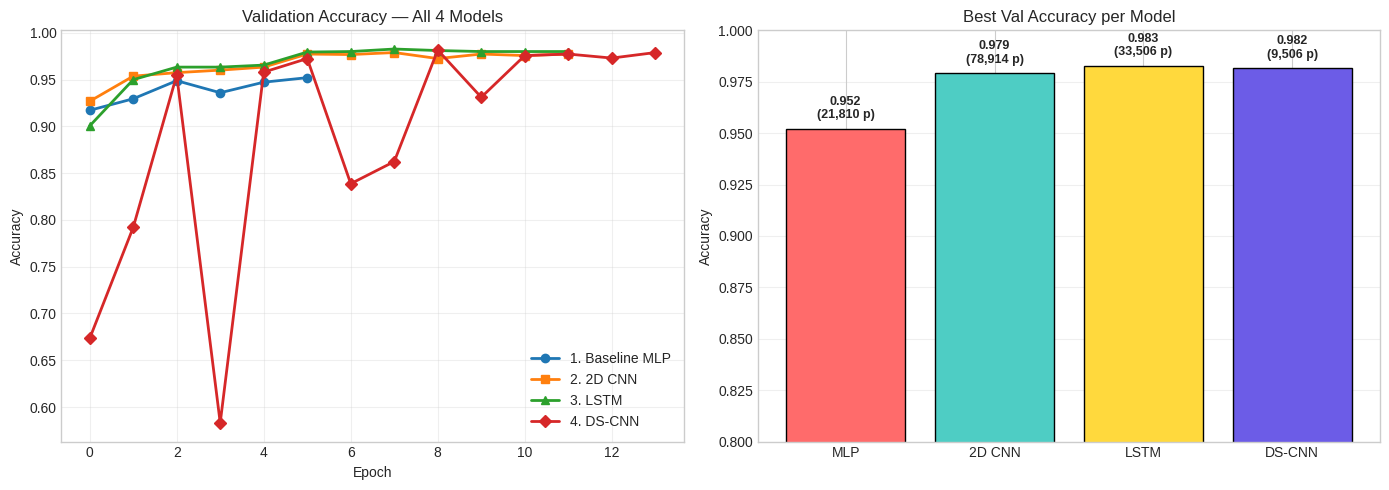


📊 SUMMARY
  Model      | Val Acc    | Params      
------------------------------------------------------------
  MLP        | 0.952      |     21,810
  2D CNN     | 0.979      |     78,914
  LSTM       | 0.983      |     33,506
  DS-CNN     | 0.982      |      9,506

🏆 Best model: LSTM with 0.983 val accuracy (33,506 params)


In [15]:
# 📊 Compare all 4 KWS models (Baseline MLP + 3 upgrades)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'],       label='1. Baseline MLP', marker='o', linewidth=2)
plt.plot(history_cnn2d.history['val_accuracy'], label='2. 2D CNN',       marker='s', linewidth=2)
plt.plot(history_lstm.history['val_accuracy'],  label='3. LSTM',         marker='^', linewidth=2)
plt.plot(history_ds.history['val_accuracy'],    label='4. DS-CNN',       marker='D', linewidth=2)
plt.title('Validation Accuracy — All 4 Models')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
names  = ['MLP', '2D CNN', 'LSTM', 'DS-CNN']
accs   = [
    max(history.history['val_accuracy']),
    max(history_cnn2d.history['val_accuracy']),
    max(history_lstm.history['val_accuracy']),
    max(history_ds.history['val_accuracy'])
]
params = [mlp_model.count_params(), model_cnn2d.count_params(),
          model_lstm.count_params(), model_ds.count_params()]
plt.bar(names, accs, color=['#ff6b6b', '#4ecdc4', '#ffd93d', '#6c5ce7'], edgecolor='black')
plt.title('Best Val Accuracy per Model')
plt.ylabel('Accuracy'); plt.ylim(0.8, 1.0)
for i, (a, p) in enumerate(zip(accs, params)):
    plt.text(i, a + 0.005, f"{a:.3f}\n({p:,} p)", ha='center', fontsize=9, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\n📊 SUMMARY")
print("=" * 60)
print(f"  {'Model':<10} | {'Val Acc':<10} | {'Params':<12}")
print("-" * 60)
for n, a, p in zip(names, accs, params):
    print(f"  {n:<10} | {a:.3f}      | {p:>10,}")
print("=" * 60)

best_idx = int(np.argmax(accs))
print(f"\n🏆 Best model: {names[best_idx]} with {accs[best_idx]:.3f} val accuracy ({params[best_idx]:,} params)")



## 📊 Benchmark Table — Final Comparison

Architecture · Total Parameters · Training Time per Epoch · Validation Accuracy

In [16]:
# 📊 Benchmark table — exactly what the rubric asks for
import pandas as pd
import numpy as np

def architecture_str(model):
    """One-line description of the model architecture."""
    layer_types = []
    for layer in model.layers:
        name = type(layer).__name__
        if name in ("InputLayer", "Reshape"):
            continue
        layer_types.append(name)
    return " → ".join(layer_types)

def avg_epoch_time(time_cb):
    if time_cb is None or not time_cb.times:
        return float("nan")
    return float(np.mean(time_cb.times))

rows = [
    {
        "Model":              "Baseline MLP",
        "Architecture":       architecture_str(mlp_model),
        "Total Parameters":   f"{mlp_model.count_params():,}",
        "Train Time / Epoch": f"{avg_epoch_time(time_mlp):.2f} s",
        "Val Accuracy":       f"{max(history.history['val_accuracy']):.3f}",
    },
    {
        "Model":              "2D CNN",
        "Architecture":       architecture_str(model_cnn2d),
        "Total Parameters":   f"{model_cnn2d.count_params():,}",
        "Train Time / Epoch": f"{avg_epoch_time(time_cnn2d):.2f} s",
        "Val Accuracy":       f"{max(history_cnn2d.history['val_accuracy']):.3f}",
    },
    {
        "Model":              "LSTM",
        "Architecture":       architecture_str(model_lstm),
        "Total Parameters":   f"{model_lstm.count_params():,}",
        "Train Time / Epoch": f"{avg_epoch_time(time_lstm):.2f} s",
        "Val Accuracy":       f"{max(history_lstm.history['val_accuracy']):.3f}",
    },
    {
        "Model":              "DS-CNN",
        "Architecture":       architecture_str(model_ds),
        "Total Parameters":   f"{model_ds.count_params():,}",
        "Train Time / Epoch": f"{avg_epoch_time(time_ds):.2f} s",
        "Val Accuracy":       f"{max(history_ds.history['val_accuracy']):.3f}",
    },
]

benchmark_df = pd.DataFrame(rows)

# Show as a wide, readable table
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

print("=" * 110)
print("📊  KWS MODEL BENCHMARK")
print("=" * 110)
print(benchmark_df.to_string(index=False))
print("=" * 110)

# Pretty HTML render in Colab/Jupyter
from IPython.display import display, HTML
display(HTML(benchmark_df.to_html(index=False, justify='center')))

# Save to CSV (handy for the report)
benchmark_df.to_csv("kws_benchmark.csv", index=False)
print("\n💾 Saved: kws_benchmark.csv")


📊  KWS MODEL BENCHMARK
       Model                                                                                                                                                                                                                                          Architecture Total Parameters Train Time / Epoch Val Accuracy
Baseline MLP                                                                                                                                                                                                                       Flatten → Dense → Dense → Dense           21,810             1.26 s        0.952
      2D CNN                                                                                                                           Conv2D → BatchNormalization → MaxPooling2D → Conv2D → BatchNormalization → MaxPooling2D → Flatten → Dropout → Dense → Dense           78,914             8.15 s        0.979
        LSTM                                         

Model,Architecture,Total Parameters,Train Time / Epoch,Val Accuracy
Baseline MLP,Flatten → Dense → Dense → Dense,"21,810",1.26 s,0.952
2D CNN,Conv2D → BatchNormalization → MaxPooling2D → Conv2D → BatchNormalization → MaxPooling2D → Flatten → Dropout → Dense → Dense,"78,914",8.15 s,0.979
LSTM,LSTM → Dropout → LSTM → Dropout → Dense → Dense,"33,506",15.86 s,0.983
DS-CNN,Conv2D → BatchNormalization → ReLU → SeparableConv2D → BatchNormalization → ReLU → MaxPooling2D → SeparableConv2D → BatchNormalization → ReLU → MaxPooling2D → SeparableConv2D → BatchNormalization → ReLU → GlobalAveragePooling2D → Dropout → Dense,"9,506",18.00 s,0.982



💾 Saved: kws_benchmark.csv


 Export the WINNER (Dropout MLP)

In [17]:

import os

def representative_dataset():
    for i in range(min(100, len(X_train_mfcc))):
        yield [X_train_mfcc[i:i+1].astype(np.float32)]

print(" Exporting the BEST model (Dropout MLP)...")
converter = tf.lite.TFLiteConverter.from_keras_model(model_drop)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()
model_path = "kws_yesno_best_model.tflite"
with open(model_path, "wb") as f:
    f.write(tflite_model)

print(f" Saved: {model_path}")
print(f" Size: {os.path.getsize(model_path)/1024:.2f} KB")


 Exporting the BEST model (Dropout MLP)...
Saved artifact at '/tmp/tmpm1rcxjxk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 51, 13, 1), dtype=tf.float32, name='mfcc_input')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133963259924688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259930448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259929680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259928144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259928912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259922384: TensorSpec(shape=(), dtype=tf.resource, name=None)
 Saved: kws_yesno_best_model.tflite
 Size: 26.27 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


 Quantize & Export to TFLite Micro (B-U585I-IOT02A Ready)

In [18]:
import os

def representative_dataset():
    # Use 100 samples from training set for int8 calibration
    for i in range(min(100, len(X_train_mfcc))):
        yield [X_train_mfcc[i:i+1].astype(np.float32)]

print(" Converting to TFLite (post-training quantization)...")
converter = tf.lite.TFLiteConverter.from_keras_model(mlp_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# Keep float32 I/O for Colab testing; X-CUBE-AI handles int8 buffer scaling on-device
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()
model_path = "kws_yesno_baseline_mlp.tflite"
with open(model_path, "wb") as f:
    f.write(tflite_model)

print(f"\n Export complete!")
print(f" Model: {model_path}")
print(f" Size: {os.path.getsize(model_path) / 1024:.2f} KB (Target: <1500 KB)")
print(f" Params: {mlp_model.count_params():,} (Target: <100K)")




 Converting to TFLite (post-training quantization)...
Saved artifact at '/tmp/tmp7ojfjof2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 51, 13, 1), dtype=tf.float32, name='mfcc_input')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133963259927760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963261606416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259928720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259930640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259929104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133963259930832: TensorSpec(shape=(), dtype=tf.resource, name=None)

 Export complete!
 Model: kws_yesno_baseline_mlp.tflite
 Size: 26.27 KB (Target: <1500 KB)
 Params: 21,810 (Target: <100K)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
